# 🏥 Cloud Cost Intelligence Platform for Healthcare
### Artificial Intelligence, Cloud Computing and DevOps-B (Final Year Project)

**Main Objective:** Develop a smart Healthcare Cloud Billing Analysis System that helps hospitals and healthcare organizations track, analyze, optimize, and predict cloud service costs.

This interactive notebook includes:
- **Data Preprocessing**: Cleaning and preparing billing data.
- **KPI Dashboard**: Advanced metrics for cloud cost management.
- **Professional Data Visualizations**: 10 distinct, interactive, and statically styled charts.
- **AI/Machine Learning**: Predictive cost modeling (Linear Regression) and Outlier/Anomaly Detection.
- **Exporting**: Excel reporting & PDF logic.


## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error, r2_score
import warnings
import ipywidgets as widgets
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#1e1e1e", "figure.facecolor": "#121212", "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white", "ytick.color": "white"})

print("✅ All libraries loaded successfully.")



✅ All libraries loaded successfully.


## 3. Data Loading & Preprocessing

In [3]:
# Load the dataset
try:
    df = pd.read_csv('healthcare_cloud_billing.csv')
    df['Date'] = pd.to_datetime(df['Date'])
    df['Month'] = df['Date'].dt.to_period('M').astype(str)
    print(f"✅ Data loaded successfully. Shape: {df.shape}")
except Exception as e:
    print(f"❌ Error loading data: {e}")

# Display first few rows
display(df.head())



✅ Data loaded successfully. Shape: (1200, 17)


,Billing ID,Hospital Name,Department Name,Service Type,Region,Usage Hours,Storage Used (GB),Monthly Cost,Date,Payment Status,Vendor Name,Resource ID,CPU Usage %,Memory Usage %,Forecast Demand,Cost Center,Month
0,INV-10416,Apollo Hospitals,IT Dept,Database,eu-west-1,672.35,332.30,161.25,2023-01-01,Paid,Google Cloud,RES-9039,6.06,69.50,172.92,CC-889,2023-01
1,INV-10730,Apollo Hospitals,Pharmacy,Security,eu-central-1,356.70,123.76,55.98,2023-01-01,Pending,Google Cloud,RES-9243,3.08,79.61,67.01,CC-637,2023-01
2,INV-10892,Tata Memorial,IT Dept,Database,ap-southeast-1,231.12,234.74,59.04,2023-01-01,Paid,Google Cloud,RES-2579,18.15,20.90,59.61,CC-833,2023-01
3,INV-10489,Apollo Hospitals,Oncology,Analytics,eu-west-1,294.47,314.15,50.45,2023-01-02,Overdue,AWS,RES-3131,37.92,16.99,53.22,CC-950,2023-01
4,INV-10546,Apollo Hospitals,Oncology,Storage,ap-southeast-1,650.03,3379.90,165.10,2023-01-03,Paid,Azure,RES-2270,8.85,86.10,186.35,CC-906,2023-01


## 4. Executive KPI Dashboard

In [4]:
# Calculate KPIs
total_monthly_cost = df[df['Date'].dt.month == df['Date'].max().month]['Monthly Cost'].sum()
total_annual_cost = df['Monthly Cost'].sum()
top_expensive_dept = df.groupby('Department Name')['Monthly Cost'].sum().idxmax()
top_expensive_service = df.groupby('Service Type')['Monthly Cost'].sum().idxmax()
pending_payments = df[df['Payment Status'] == 'Pending']['Monthly Cost'].sum()

# Display KPIs using HTML/CSS Cards
kpi_html = f"""
<div style='display:flex; justify-content:space-around; flex-wrap:wrap; text-align:center;'>
    <div style='background-color:#2b2b2b; padding:20px; border-radius:10px; margin:10px; width:18%; border-left: 5px solid #00c3ff;'>
        <h4 style='color:#ccc; margin:0;'>Total Cost (YTD)</h4>
        <h2 style='color:#00c3ff; margin:10px 0;'>${total_annual_cost:,.2f}</h2>
    </div>
    <div style='background-color:#2b2b2b; padding:20px; border-radius:10px; margin:10px; width:18%; border-left: 5px solid #ff4b4b;'>
        <h4 style='color:#ccc; margin:0;'>Recent Month Cost</h4>
        <h2 style='color:#ff4b4b; margin:10px 0;'>${total_monthly_cost:,.2f}</h2>
    </div>
    <div style='background-color:#2b2b2b; padding:20px; border-radius:10px; margin:10px; width:18%; border-left: 5px solid #ffcc00;'>
        <h4 style='color:#ccc; margin:0;'>Pending Payments</h4>
        <h2 style='color:#ffcc00; margin:10px 0;'>${pending_payments:,.2f}</h2>
    </div>
    <div style='background-color:#2b2b2b; padding:20px; border-radius:10px; margin:10px; width:18%; border-left: 5px solid #00ff99;'>
        <h4 style='color:#ccc; margin:0;'>Top Dept</h4>
        <h3 style='color:#00ff99; margin:10px 0;'>{top_expensive_dept}</h3>
    </div>
    <div style='background-color:#2b2b2b; padding:20px; border-radius:10px; margin:10px; width:18%; border-left: 5px solid #cc00ff;'>
        <h4 style='color:#ccc; margin:0;'>Top Service</h4>
        <h3 style='color:#cc00ff; margin:10px 0;'>{top_expensive_service}</h3>
    </div>
</div>
"""
display(HTML(kpi_html))



## 5. Advanced Data Visualizations
### 5.1 Service Cost Distribution (Pie Chart)

In [5]:
service_costs = df.groupby('Service Type')['Monthly Cost'].sum().reset_index()
fig1 = px.pie(service_costs, values='Monthly Cost', names='Service Type', hole=0.3,
             title='Cloud Service Cost Distribution', color_discrete_sequence=px.colors.sequential.Plasma)
fig1.update_layout(template='plotly_dark')
fig1.show()



### 5.2 Department Cost Comparison (Bar Chart)

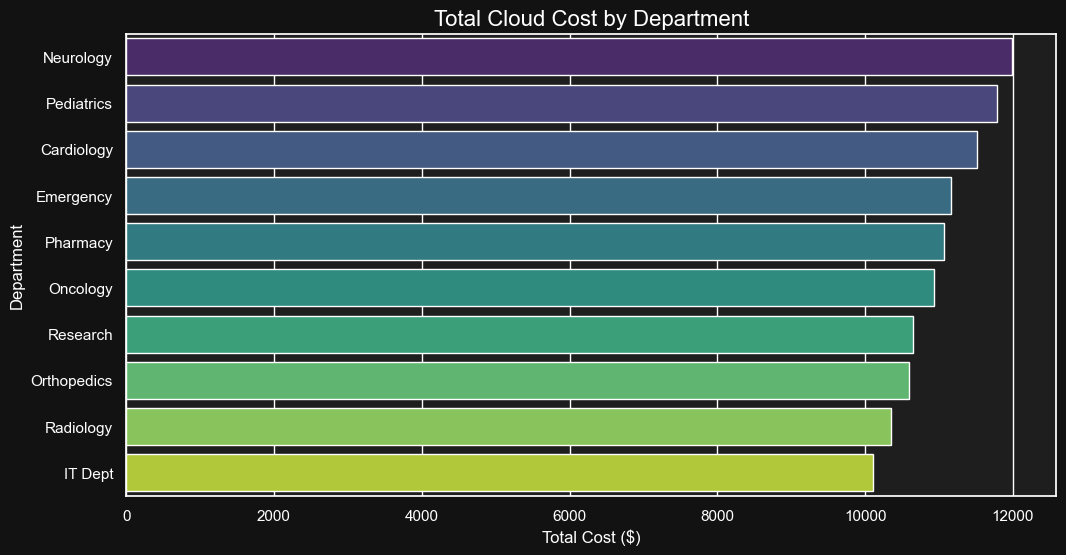

In [6]:
dept_costs = df.groupby('Department Name')['Monthly Cost'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='Monthly Cost', y='Department Name', data=dept_costs, palette='viridis')
plt.title('Total Cloud Cost by Department', fontsize=16, color='white')
plt.xlabel('Total Cost ($)', color='white')
plt.ylabel('Department', color='white')
plt.show()



### 5.3 Monthly Cost Trend (Line Chart)

In [7]:
monthly_trend = df.groupby('Month')['Monthly Cost'].sum().reset_index()
fig3 = px.line(monthly_trend, x='Month', y='Monthly Cost', markers=True, 
               title='Monthly Cloud Cost Trend', line_shape='spline')
fig3.update_traces(line_color='#00ff99', line_width=3, marker=dict(size=8, color='white'))
fig3.update_layout(template='plotly_dark', xaxis_title='Month', yaxis_title='Cost ($)')
fig3.show()



### 5.4 Vendor Share (Donut Chart)

In [8]:
vendor_share = df.groupby('Vendor Name')['Monthly Cost'].sum().reset_index()
fig4 = px.pie(vendor_share, values='Monthly Cost', names='Vendor Name', hole=0.5,
              title='Cloud Provider Market Share', color_discrete_sequence=['#ff9900', '#0078d4', '#ea4335'])
fig4.update_layout(template='plotly_dark')
fig4.show()



### 5.5 Department vs Cost (Heatmap)

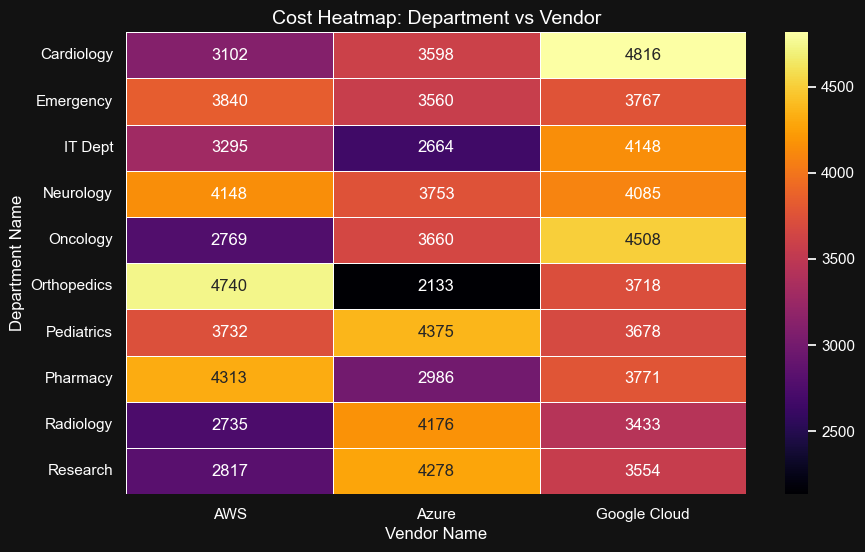

In [9]:
heatmap_data = df.pivot_table(index='Department Name', columns='Vendor Name', values='Monthly Cost', aggfunc='sum').fillna(0)
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="inferno", linewidths=.5)
plt.title('Cost Heatmap: Department vs Vendor', color='white', fontsize=14)
plt.show()



### 5.7 CPU Usage vs Cost (Scatter Plot)

In [11]:
fig7 = px.scatter(df, x='CPU Usage %', y='Monthly Cost', color='Service Type',
                    size='Usage Hours', hover_data=['Department Name'],
                    title='CPU Usage vs Monthly Cost (Sized by Usage Hours)')
fig7.update_layout(template='plotly_dark')
fig7.show()



### 5.10 Cumulative Yearly Growth (Area Chart)

In [14]:
df_sorted = df.sort_values('Date')
monthly_sum = df_sorted.groupby('Month')['Monthly Cost'].sum().reset_index()
monthly_sum['Cumulative Cost'] = monthly_sum['Monthly Cost'].cumsum()

fig10 = px.area(monthly_sum, x='Month', y='Cumulative Cost', title='Cumulative Cloud Cost Growth over Time',
                color_discrete_sequence=['#ff4b4b'])
fig10.update_layout(template='plotly_dark')
fig10.show()



## 6. AI & Smart Features
### 6.1 Predicting Next Month Cost (Linear Regression)

🤖 Model Performance: MSE = 48453.10, R2 Score = 0.03


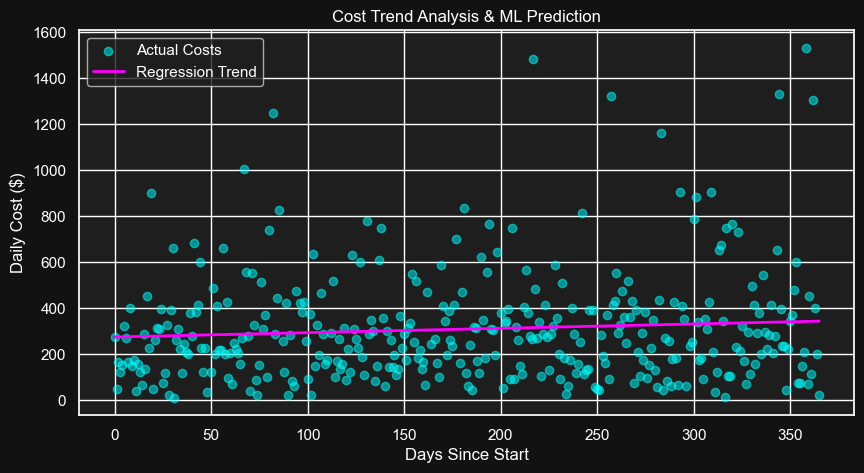

In [15]:
# Preparing data for ML
ml_df = df.groupby('Date')['Monthly Cost'].sum().reset_index()
ml_df['Day_Index'] = (ml_df['Date'] - ml_df['Date'].min()).dt.days

X = ml_df[['Day_Index']]
y = ml_df['Monthly Cost']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"🤖 Model Performance: MSE = {mse:.2f}, R2 Score = {r2:.2f}")

# Predict next 30 days
future_days = np.array([[X['Day_Index'].max() + i] for i in range(1, 31)])
future_preds = model.predict(future_days)
predicted_next_month_cost = future_preds.sum()

display(HTML(f"<h4>🔮 Predicted Cloud Cost for Next 30 Days: <span style='color:lime'>${predicted_next_month_cost:,.2f}</span></h4>"))

# Plot Regression Line
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='cyan', label='Actual Costs', alpha=0.5)
plt.plot(X, model.predict(X), color='magenta', linewidth=2, label='Regression Trend')
plt.title('Cost Trend Analysis & ML Prediction', color='white')
plt.xlabel('Days Since Start', color='white')
plt.ylabel('Daily Cost ($)', color='white')
plt.legend()
plt.show()



### 6.2 Anomaly Detection (Isolation Forest)

In [16]:
# Detecting Abnormal High Bills
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['Anomaly'] = iso_forest.fit_predict(df[['Monthly Cost', 'Usage Hours']])

anomalies = df[df['Anomaly'] == -1]
print(f"🚨 Detected {len(anomalies)} abnormal billing records!")
display(anomalies[['Billing ID', 'Department Name', 'Service Type', 'Monthly Cost']].head())

# Visualizing Anomalies
fig11 = px.scatter(df, x='Usage Hours', y='Monthly Cost', color=df['Anomaly'].astype(str),
                   title='Anomaly Detection in Cloud Billing (Red = Outliers)',
                   color_discrete_map={'-1': 'red', '1': '#00ff99'})
fig11.update_layout(template='plotly_dark')
fig11.show()



🚨 Detected 60 abnormal billing records!


,Billing ID,Department Name,Service Type,Monthly Cost
40,INV-10150,Orthopedics,Compute,259.51
52,INV-11067,IT Dept,Backup,329.13
64,INV-10538,Research,Security,256.25
86,INV-10262,Neurology,Database,171.72
122,INV-10806,IT Dept,Analytics,419.61
